In [30]:
import sys

from pathlib import Path

import numpy as np
import torch
import tqdm.auto as tqdm

import matplotlib.pyplot as plt

In [2]:
src_directory = Path('../src')
init_directory = src_directory / 'initialization'
src_path = Path('../src')
sys.path.append(str(src_path))

In [3]:
from signalmodel_epg import calculate_signal_epg

In [9]:
FA_DATA_PATH = init_directory / 'fa_cao.npy'
TR_DATA_PATH = init_directory / 'tr_cao.npy'
fa = np.load(FA_DATA_PATH)
tr = np.load(TR_DATA_PATH)

Text(0.5, 0, 'TR Index')

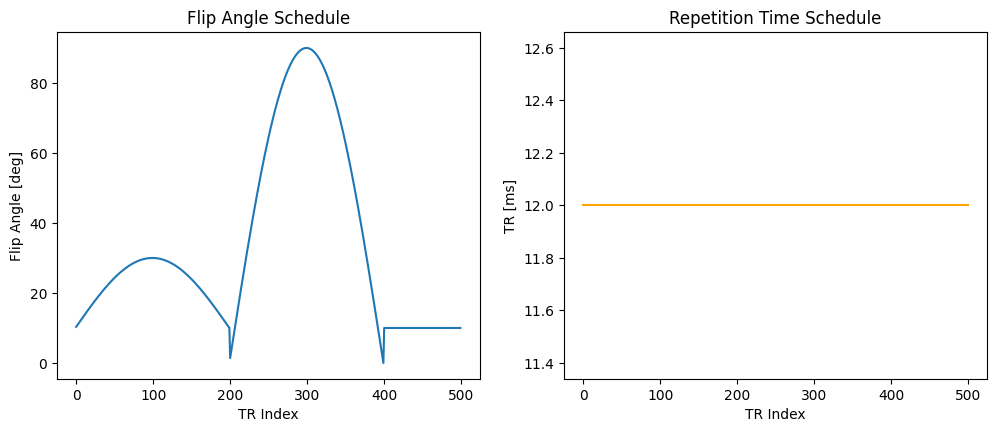

In [14]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(fa, label='Flip Angle (degrees)')
ax.set_title('Flip Angle Schedule')
ax.set_ylabel('Flip Angle [deg]')
ax.set_xlabel('TR Index')

ax = axes[1]
ax.plot(tr, label='Repetition Time (ms)', color='orange')
ax.set_title('Repetition Time Schedule')
ax.set_ylabel('TR [ms]')
ax.set_xlabel('TR Index')

Here we set up the relaxometric parameters for out simulation and optimization:

In [15]:
M0: float = 1.0 # Equilibrium magnetization
T1 = np.array(
    [500, 1000, 1500], dtype=np.float32
)
T2 = np.array(
    [250, 500, 750], dtype=np.float32
)
T1, T2 = np.meshgrid(T1, T2)
T1 = torch.as_tensor(T1.flatten())
T2 = torch.as_tensor(T2.flatten())

We also need sequence-specific parameters for our fingerprinting data acquisition protocol.
We especially focus on parameters that occur for the sequence template laid out in the inversion recovery fast imaging by steady-state free prescession (IR-FISP)
sequence by [Jiang et al.](https://pubmed.ncbi.nlm.nih.gov/25491018/)

In [28]:
TI: float = [10.0]  # Inversion time in ms
TE: float = 1.0  # Echo time in ms
inversion_efficiency: float = 0.96  # Inversion efficiency
delta_B1: float = 1.0  # B1+ inhomogeneity scaling factor, 1.0 means perfect transmission
phase: float = np.zeros_like(fa)  # RF phase in radians

beats: int = 1 # number of different readout blocks
shots: int = len(fa) # number of excitations per block
prep: list[int] = [1]  # integer code for preparation module, 1 means inversion pulse at the beginning of each block
t2te: list[float] = [0.0]  # T2 preparation echo time in ms

In [34]:
signals: list[torch.Tensor] = []
for t1v, t2v in tqdm.tqdm(list(zip(T1, T2)), desc='Simulating signals', unit='signal'):
    kwargs = {
        't1' : t1v,
        't2' : t2v,
        'm0' : M0,
        'beats' : beats,
        'shots' : shots,
        'fa' : fa,
        'tr' : tr,
        'ph' : phase,
        'prep' : prep,
        't2te' : t2te,
        'ti' : TI,
        'te' : TE
    }
    signals.append(calculate_signal_epg(**kwargs))
signals = torch.stack(signals)

Simulating signals:   0%|          | 0/9 [00:00<?, ?signal/s]

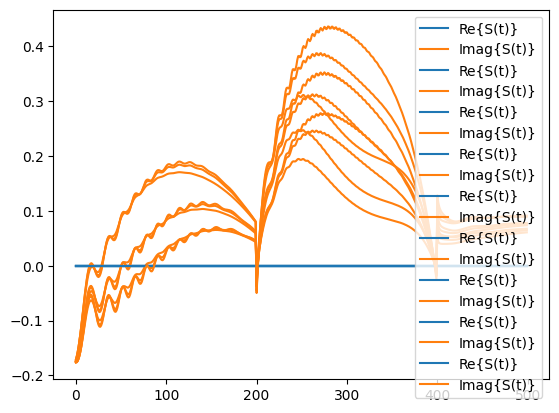

In [ ]:
fig, ax = plt.subplots()
for s in signals:
    s = s.detach().cpu().numpy()
    ax.plot(s.real, color='tab:blue', label=r'Re[S(t)]')
    ax.plot(s.imag, color='tab:orange', label=r'Imag[S(t)]')

ax.legend()